In [1]:
import torch
import os
import sys

import numpy as np
from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy
import seaborn as sb

import matplotlib.pyplot as plt
import random as rd
import pickle as pkl

2025-07-03 17:10:29.450487: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-03 17:10:29.479477: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-07-03 17:10:30.143402: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Parameters

In [2]:
exp_id = 0
exp_name = "MNIST"
batch_size = 256
data_path = os.getcwd() + "/data/MNIST"
train_correlation, test_correlation = 0.7, 0.1
epochs = 50
layer_depth = 4
number_of_concepts = 40
patch_size = 8
concept_dataset_size = 2000

# Loading the model and dataset

In [3]:
current_path = os.getcwd()
train_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=train_correlation, train=True)
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=test_correlation, train=False)

for X, y, _ in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1 = nn.Sequential(nn.Linear(28*28*3, 512), nn.ReLU())
        self.l2 = nn.Sequential(nn.Linear(512, 512), nn.ReLU())
        self.l3 = nn.Sequential(nn.Linear(512, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.l1(x)
        x = self.l2(x)
        logits = self.l3(x)
        return logits

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
model

Shape of X [N, C, H, W]: torch.Size([256, 3, 28, 28])
Shape of y: torch.Size([256]) torch.int64
Using cuda device


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (l1): Sequential(
    (0): Linear(in_features=2352, out_features=512, bias=True)
    (1): ReLU()
  )
  (l2): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
  )
  (l3): Sequential(
    (0): Linear(in_features=512, out_features=10, bias=True)
  )
)

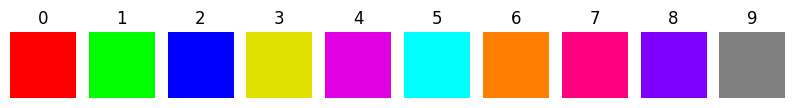

In [4]:
COLOUR_MAP = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [225, 225, 0], [225, 0, 225],
                  [0, 255, 255], [255, 128, 0], [255, 0, 128], [128, 0, 255], [128, 128, 128]]
fig, axes = plt.subplots(1,10, figsize=(10,10))
for label, color in enumerate(COLOUR_MAP):
    axes[label].set_axis_off()
    axes[label].set_title(loc="center", label=f"{label}")
    axes[label].imshow([[color]])

In [5]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y, _) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if (batch *batch_size)% 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    appearance_matrix = []
    correctness_matrix = None
    confusion = []
    with torch.no_grad():
        for X, y, y_pred in dataloader:
            X, y, y_pred = X.to(device), y.to(device), y_pred.to(device)
            pred = model(X)
            if len(appearance_matrix)==0:
                size_y = len(pred[0])
                appearance_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
                correctness_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
                confusion_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            for i in range(size_y):
                for j in range(size_y):
                    appearance_matrix[i][j] += int(((y==i) & (y_pred==j)).sum())
                    correctness_matrix[i][j] += int((pred.argmax(1)[((y==i) & (y_pred==j))] == i).sum())
                    confusion_matrix[i][j] += int(((y==i) & (pred.argmax(1)==j)).sum())
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    accuracy_matrix = correctness_matrix/appearance_matrix
    return accuracy_matrix, confusion_matrix

assert(os.path.exists(f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}"))
model.load_state_dict(torch.load(f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}", weights_only=True))

biased_perf, biased_confusion = test(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 77.2%, Avg loss: 0.670828 



# Loading craft

In [6]:
g = nn.Sequential(*(list(model.children())[:layer_depth-1]))
h = nn.Sequential(*(list(model.children())[layer_depth-1:]))

craft = Craft(
    input_to_latent=g,
    latent_to_logit = h,
    number_of_concepts = number_of_concepts,
    patch_size = patch_size,
    batch_size = batch_size,
    device = device
)
g, h

(Sequential(
   (0): Flatten(start_dim=1, end_dim=-1)
   (1): Sequential(
     (0): Linear(in_features=2352, out_features=512, bias=True)
     (1): ReLU()
   )
   (2): Sequential(
     (0): Linear(in_features=512, out_features=512, bias=True)
     (1): ReLU()
   )
 ),
 Sequential(
   (0): Sequential(
     (0): Linear(in_features=512, out_features=10, bias=True)
   )
 ))

In [7]:
from sklearn.decomposition import NMF
concept_path = f"models/concepts_{exp_name}_model_{exp_id}_{epochs}_{train_correlation}_{number_of_concepts}"
with open(concept_path, "rb") as f:
    crops, crops_u, W, reducer, bias_concepts = pkl.load(f)
craft.reducer = reducer
craft.W = np.array(W, dtype=np.float32)

In [8]:
# class_label = 5
# class_dataset_size = 300

# class_dataset = torch.Tensor([])
# for X, y, y_pred in test_dataloader:
#     class_dataset = torch.cat((class_dataset, X[y == class_label]))
#     if len(class_dataset) >= class_dataset_size:
#       class_dataset = class_dataset[:class_dataset_size]
#       break


# importances = craft.estimate_importance(class_dataset, class_id=class_label)
# images_u = craft.transform(class_dataset)

# images_u.shape

# plt.bar(range(len(importances)), importances)
# plt.xticks(range(len(importances)))
# plt.title("Concept Importance")

# most_important_concepts = np.argsort(importances)[::-1]

# for c_id in most_important_concepts:
#   print("Concept", c_id, " has an importance value of ", importances[c_id])

In [9]:
class Activation_disturber():
    def __init__(self,  layer, concepts, cr, device = "cuda"):
        self.cr = cr
        self.concepts = concepts
        self.handle = layer.register_forward_hook(self._hook_function)
        self.device = device
    
    def _hook_function(self, model, input, output):
        concepts_activation = craft.transform(inputs=None, activations=output)
        res = output - torch.Tensor(concepts_activation[:,self.concepts] @ self.cr.W[self.concepts]).to(device)
        # res = output + torch.Tensor(0.05 * np.ones_like(concepts_activation[:,self.concepts]) @ self.cr.W[self.concepts]).to(device)
        return res

    def __del__(self):
        self.handle.remove()

ad = Activation_disturber(g[-1], bias_concepts, craft)

In [10]:
new_perf, new_confusion = test(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 77.1%, Avg loss: 0.688839 



In [11]:
def mmetric(input):
    center = np.ones_like(input)
    for i in range(len(input)):
        center[i] = input[i] - input[i].mean()
    center = (center**2).sum(axis=1)/input.shape[1]
    return np.sqrt(center)

The variance is of 0.18040641488114895


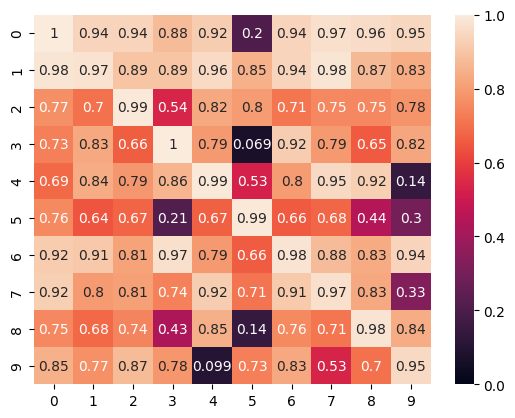

In [12]:
sb.heatmap(biased_perf, vmin=0, vmax=1, annot=True)
print(f"The variance is of {mmetric(biased_perf).mean()}")

The variance is of 0.16863746066157334


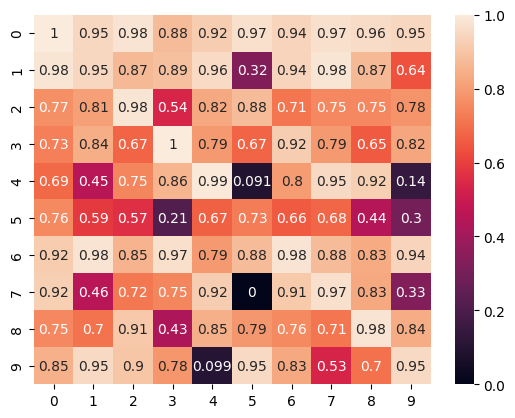

In [13]:
sb.heatmap(new_perf, vmin=0, vmax=1, annot=True)
print(f"The variance is of {mmetric(new_perf).mean()}")

The difference in accuracy is of 0.0001


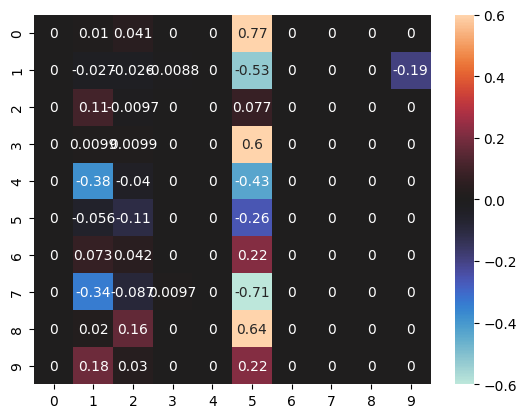

In [14]:
sb.heatmap(new_perf - biased_perf, vmin=-0.6, vmax=0.6, annot=True, cmap="icefire")
print(f"The difference in accuracy is of {np.round((new_perf - biased_perf).sum()/100,4)}")

<Axes: >

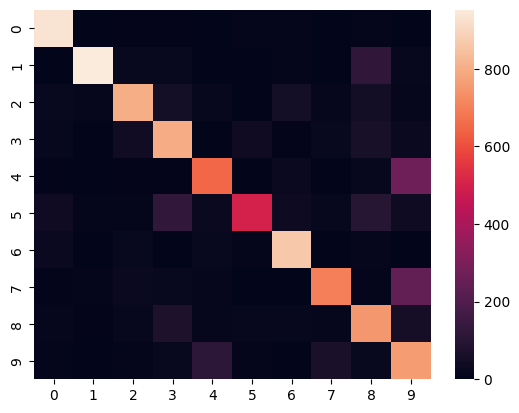

In [15]:
sb.heatmap(new_confusion)

In [16]:
for el in list(model.children())[:layer_depth-1]:
    for param in el.parameters():
        param.requires_grad = False

In [18]:
accuracy_matrixes = []
epochs = 4
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    ac_matrix, confusion_matrix = test(test_dataloader, model, loss_fn)
    accuracy_matrixes.append(ac_matrix)
print("Done!")

Epoch 1
-------------------------------
loss: 0.351894  [  256/60000]
loss: 0.386073  [ 6656/60000]
loss: 0.326766  [13056/60000]
loss: 0.345755  [19456/60000]
loss: 0.324381  [25856/60000]
loss: 0.404750  [32256/60000]
loss: 0.359736  [38656/60000]
loss: 0.371291  [45056/60000]
loss: 0.368420  [51456/60000]
loss: 0.361496  [57856/60000]
Test Error: 
 Accuracy: 77.9%, Avg loss: 0.662680 

Epoch 2
-------------------------------
loss: 0.326482  [  256/60000]
loss: 0.446217  [ 6656/60000]
loss: 0.366025  [13056/60000]
loss: 0.288304  [19456/60000]
loss: 0.387914  [25856/60000]
loss: 0.387636  [32256/60000]
loss: 0.386095  [38656/60000]
loss: 0.361322  [45056/60000]
loss: 0.353037  [51456/60000]
loss: 0.310371  [57856/60000]
Test Error: 
 Accuracy: 78.0%, Avg loss: 0.661874 

Epoch 3
-------------------------------
loss: 0.317718  [  256/60000]
loss: 0.286540  [ 6656/60000]
loss: 0.350171  [13056/60000]
loss: 0.306330  [19456/60000]
loss: 0.375110  [25856/60000]
loss: 0.315362  [32256/600

The variance is of 0.16221038154503384


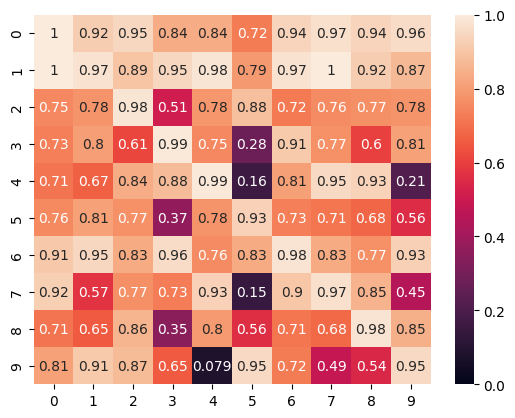

In [19]:
sb.heatmap(accuracy_matrixes[-1], vmin=0, vmax=1, annot=True)
print(f"The variance is of {mmetric(accuracy_matrixes[-1]).mean()}")

The variance is of 0.16863746066157334


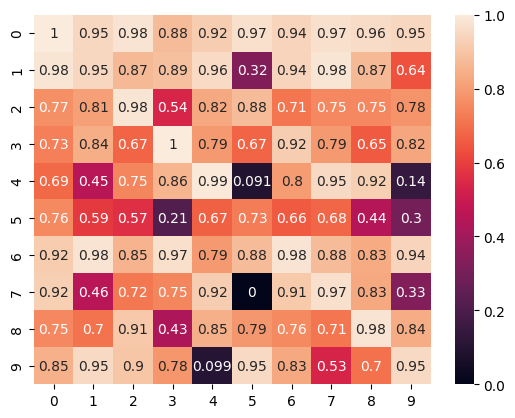

In [20]:
sb.heatmap(new_perf, vmin=0, vmax=1, annot=True)
print(f"The variance is of {mmetric(new_perf).mean()}")

The difference in accuracy is of 0.0001


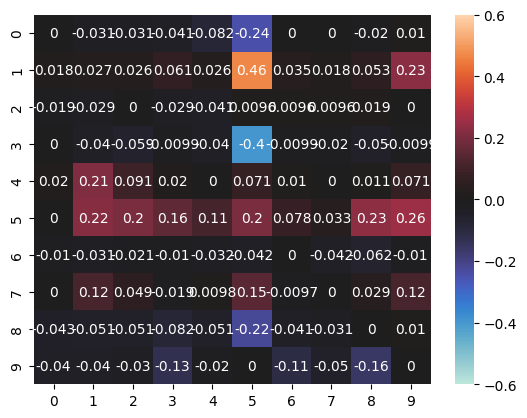

In [21]:
sb.heatmap(accuracy_matrixes[-1] - new_perf, vmin=-0.6, vmax=0.6, annot=True, cmap="icefire")
print(f"The difference in accuracy is of {np.round((new_perf - biased_perf).sum()/100,4)}")

The difference in accuracy is of 0.0001


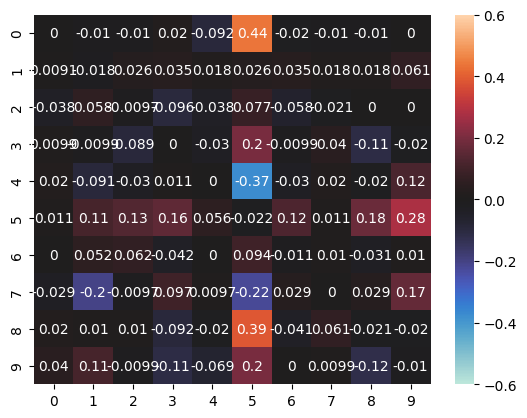

In [ ]:
sb.heatmap(accuracy_matrixes[-1] - biased_perf, vmin=-0.6, vmax=0.6, annot=True, cmap="icefire")
print(f"The difference in accuracy is of {np.round((new_perf - biased_perf).sum()/100,4)}")